# Project Prophet - People in Shelter

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from tools.metrics import measuring_predictions, model_assessment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric, add_changepoints_to_plot
from datetime import datetime

In [16]:
df = pd.read_csv("./data/DHS_weekly.csv", parse_dates=True)
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Total Individuals in Shelter,Easter,Thanksgiving,Christmas,Temperature
0,2014-01-05,354354,0,0,0,0.848000
1,2014-01-12,358103,0,0,0,3.257143
2,2014-01-19,359491,0,0,0,5.632857
3,2014-01-26,362880,0,0,0,-1.850000
4,2014-02-02,364125,0,0,0,1.177143


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ds                            366 non-null    datetime64[us]
 1   Total Individuals in Shelter  366 non-null    int64         
 2   Easter                        366 non-null    int64         
 3   Thanksgiving                  366 non-null    int64         
 4   Christmas                     366 non-null    int64         
 5   Temperature                   366 non-null    float64       
 6   y                             366 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(4)
memory usage: 20.1 KB


In [17]:
df = df.rename(
    columns={"Date": "ds"}
)

df["y"] = df["Total Individuals in Shelter"] / 1000

df.head()

,ds,Total Individuals in Shelter,Easter,Thanksgiving,Christmas,Temperature,y
0,2014-01-05,354354,0,0,0,0.848000,354.354
1,2014-01-12,358103,0,0,0,3.257143,358.103
2,2014-01-19,359491,0,0,0,5.632857,359.491
3,2014-01-26,362880,0,0,0,-1.850000,362.880
4,2014-02-02,364125,0,0,0,1.177143,364.125


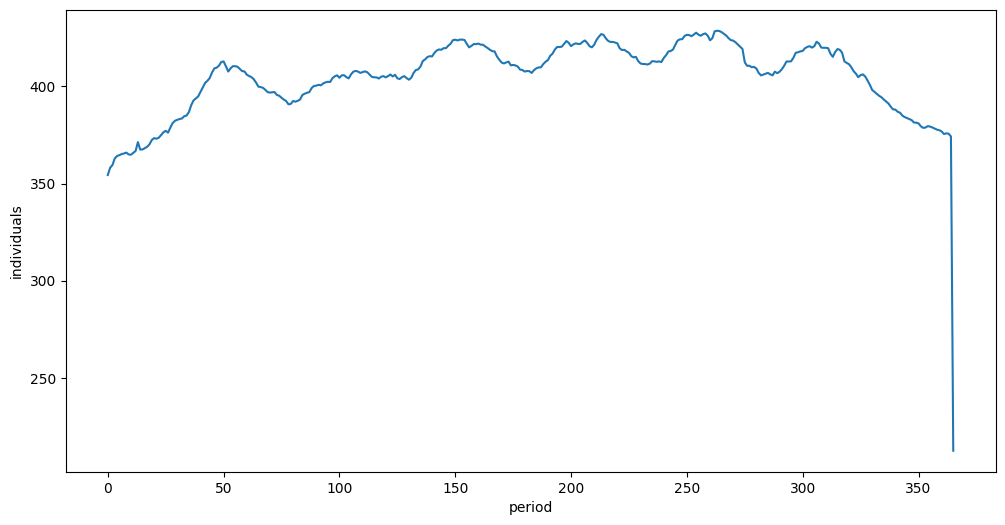

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df["y"])
plt.xlabel("period")
plt.ylabel("individuals")
plt.show()

In [ ]:
df.tail(1)

,ds,Total Individuals in Shelter,Easter,Thanksgiving,Christmas,Temperature,y
365,2021-01-03,212514,0,0,0,6.625,212.514


The lowest value of the series may impact the forecasting, so we gotta change this value.

In this case, the lowest value is in the 3rd day of january.
I'll make an average of the 3rd day of january of all years and replace this one

In [48]:
dates_to_get = df.groupby(df["ds"].dt.month).agg({"ds": "min"}).reset_index(drop=True).to_numpy().tolist()
dates_to_get = [date[0] for date in dates_to_get]

mean_first_values = df.loc[df["ds"].isin(dates_to_get)]["y"].mean()
mean_first_values

np.float64(379.29325)

In [ ]:
df.loc[df["ds"]==datetime(2021, 1, 3), "y"] = mean_first_values

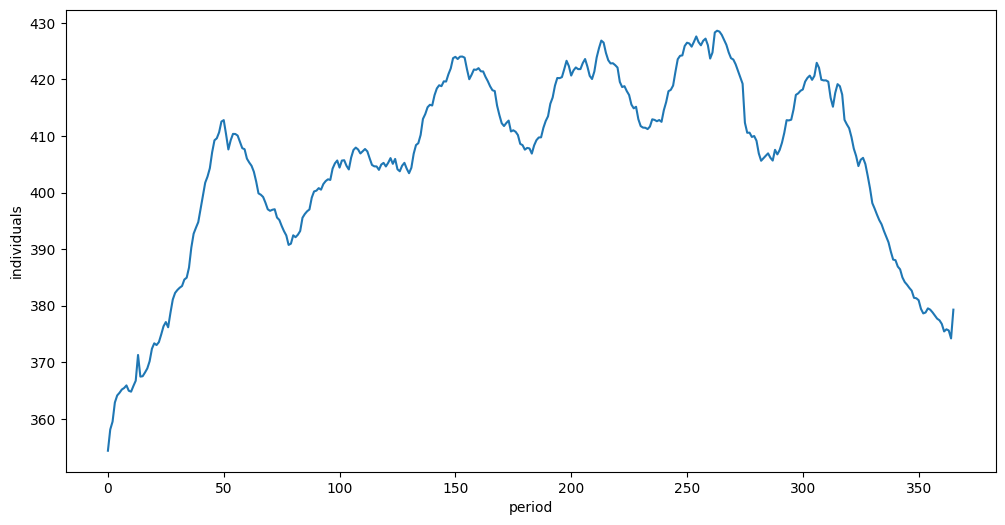

In [53]:
plt.figure(figsize=(12, 6))
plt.plot(df["y"])
plt.xlabel("period")
plt.ylabel("individuals")
plt.show()

In [56]:
easter = df.loc[df["Easter"]==1, "ds"]
thanksgiving = df.loc[df["Thanksgiving"]==1, "ds"]
christmas = df.loc[df["Christmas"]==1, "ds"]

holidays = pd.concat([
    pd.DataFrame({"holiday": "Easter", "ds": easter, "lower_window": -1, "upper_window": 1}),
    pd.DataFrame({"holiday": "Thanksgiving", "ds": easter, "lower_window": -1, "upper_window": 1}),
    pd.DataFrame({"holiday": "Christmas", "ds": easter, "lower_window": -3, "upper_window": 3}),
])

In [57]:
holidays

,holiday,ds,lower_window,upper_window
15,Easter,2014-04-20,-1,1
65,Easter,2015-04-05,-1,1
116,Easter,2016-03-27,-1,1
171,Easter,2017-04-16,-1,1
221,Easter,2018-04-01,-1,1
276,Easter,2019-04-21,-1,1
327,Easter,2020-04-12,-1,1
15,Thanksgiving,2014-04-20,-1,1
65,Thanksgiving,2015-04-05,-1,1
116,Thanksgiving,2016-03-27,-1,1


In [62]:
periods_cut = 12

train = df.iloc[:-periods_cut]
test = df.iloc[-periods_cut:]

y_train = train["y"]
y_test = test["y"]

In [61]:
model = Prophet(
    growth="linear",
    changepoint_range=0.9,
    changepoint_prior_scale=0.05,
    n_changepoints=25,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    seasonality_prior_scale=10.0,
    holidays=holidays,
    interval_width=0.95,
    mcmc_samples=0,
)

model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=5,
    prior_scale=5.0
)

model.add_regressor("Temperature", prior_scale=10.0, standardize=True)

model.fit(train.loc[:, ["ds", "y", "Temperature"]])

12:18:54 - cmdstanpy - INFO - Chain [1] start processing
12:18:54 - cmdstanpy - INFO - Chain [1] done processing


### Forecasting

In [65]:
future_test = test.loc[:, ["ds", "Temperature"]]
forecast_test = model.predict(future_test)
forecast_test.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas,Christmas_lower,Christmas_upper,Easter,...,monthly,monthly_lower,monthly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-10-18,379.169103,379.977056,384.928807,379.127668,379.224664,0.0,0.0,0.0,0.0,...,0.473493,0.473493,0.473493,3.119661,3.119661,3.119661,0.0,0.0,0.0,382.570690
1,2020-10-25,378.259659,379.771124,384.553793,378.066096,378.537219,0.0,0.0,0.0,0.0,...,0.609999,0.609999,0.609999,3.713016,3.713016,3.713016,0.0,0.0,0.0,382.316784
2,2020-11-01,377.350215,379.339531,384.351021,376.871066,377.926158,0.0,0.0,0.0,0.0,...,0.084007,0.084007,0.084007,4.319832,4.319832,4.319832,0.0,0.0,0.0,381.841363
3,2020-11-08,376.440771,377.852963,383.249711,375.515619,377.444028,0.0,0.0,0.0,0.0,...,-0.368072,-0.368072,-0.368072,4.643201,4.643201,4.643201,0.0,0.0,0.0,380.677829
4,2020-11-15,375.531327,377.389239,382.954577,374.120733,376.930664,0.0,0.0,0.0,0.0,...,0.083510,0.083510,0.083510,4.657264,4.657264,4.657264,0.0,0.0,0.0,380.183403


In [72]:
y_pred = forecast_test.set_index("ds")["yhat"]

In [80]:
measuring_predictions(test.set_index("ds")["y"], y_pred)

Mean Absolute Error: 2.72
Root Mean Squared Error: 3.30
Mean Absolute Percentage Error: 0.72%
Model's Accuracy: 99.28%


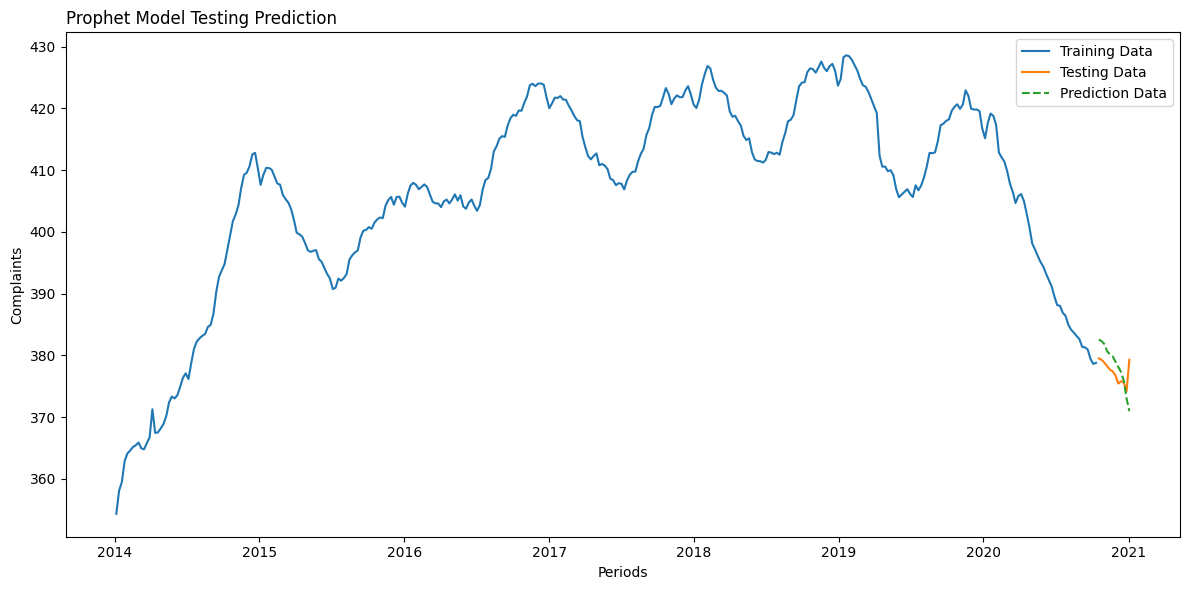

In [79]:
model_assessment(train.set_index("ds")["y"], test.set_index("ds")["y"], y_pred, "Prophet Model Testing Prediction")

### Predicting the Future

In [68]:
future = model.make_future_dataframe(periods=26, freq="W")
temp_mean = df.groupby(df["ds"].dt.month)["Temperature"].mean().rename("month_avg")
future["month"] = future["ds"].dt.month
future = future.merge(temp_mean, left_on="month", right_index=True, how="left")
future["Temperature"] = future["month_avg"]
future = future.drop(columns=["month", "month_avg"])

forecast = model.predict(future)

In [82]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas,Christmas_lower,Christmas_upper,Easter,...,monthly,monthly_lower,monthly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-05,353.120619,352.865951,357.807092,353.120619,353.120619,0.0,0.0,0.0,0.0,...,-0.460187,-0.460187,-0.460187,1.797439,1.797439,1.797439,0.0,0.0,0.0,355.275130
1,2014-01-12,354.289678,355.783247,360.484364,354.289678,354.289678,0.0,0.0,0.0,0.0,...,0.443611,0.443611,0.443611,2.627458,2.627458,2.627458,0.0,0.0,0.0,358.178006
2,2014-01-19,355.458738,358.495772,363.348571,355.458738,355.458738,0.0,0.0,0.0,0.0,...,0.677052,0.677052,0.677052,3.957373,3.957373,3.957373,0.0,0.0,0.0,360.910420
3,2014-01-26,356.627797,360.039035,364.942124,356.627797,356.627797,0.0,0.0,0.0,0.0,...,0.234576,0.234576,0.234576,4.737594,4.737594,4.737594,0.0,0.0,0.0,362.417225
4,2014-02-02,357.796856,360.484817,365.516738,357.796856,357.796856,0.0,0.0,0.0,0.0,...,-0.287410,-0.287410,-0.287410,4.515186,4.515186,4.515186,0.0,0.0,0.0,362.865260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,2021-03-14,360.070780,349.105276,375.000863,348.230765,373.223891,0.0,0.0,0.0,0.0,...,-0.146748,-0.146748,-0.146748,0.727324,0.727324,0.727324,0.0,0.0,0.0,361.339028
376,2021-03-21,359.161336,347.027546,374.857208,346.601334,373.346753,0.0,0.0,0.0,0.0,...,0.282769,0.282769,0.282769,0.204618,0.204618,0.204618,0.0,0.0,0.0,360.336393
377,2021-03-28,358.251892,345.280360,374.151124,344.691036,373.569845,0.0,0.0,0.0,0.0,...,0.097258,0.097258,0.097258,-0.065521,-0.065521,-0.065521,0.0,0.0,0.0,358.971300
378,2021-04-04,357.342448,342.534833,372.885243,342.628677,373.345631,0.0,0.0,0.0,0.0,...,-0.475671,-0.475671,-0.475671,-0.392692,-0.392692,-0.392692,0.0,0.0,0.0,356.752849


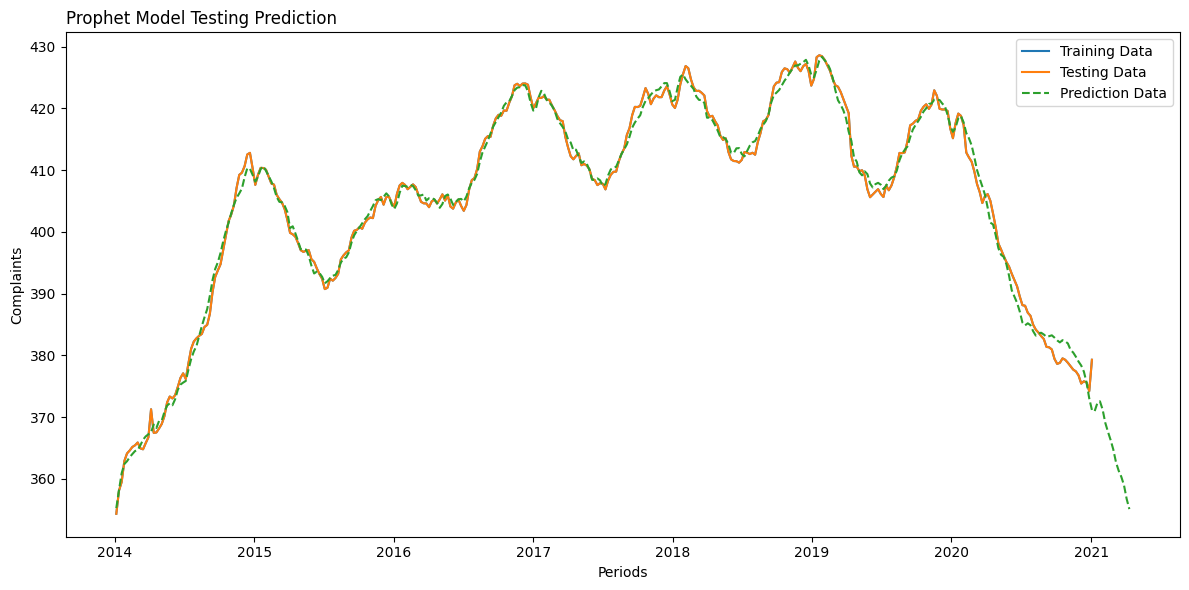

In [85]:
model_assessment(df.set_index("ds")["y"], df.set_index("ds")["y"], forecast.set_index("ds")["yhat"], "Prophet Model Testing Prediction")